# Analyse GDELT — Bénin 2025 : 5 Questions Clés


Ce notebook répond à **5 questions analytiques** précises, chacune débouchant sur une visualisation conçue pour être lisible et pertinente.

| # | Question | Visualisation |
|---|---|---|
| 1 | Quels sont les 50 médias qui parlent le plus du Bénin ? | Treemap |
| 2 | À quel moment le ton était-il le plus positif/négatif ? Sur quels sujets ? | Courbe + Barres |
| 3 | Quand le Bénin a-t-il le plus « buzzé » ? | Area Chart + Courbe |
| 4 | Quels sont les 10 sujets avec le plus grand buzz ? | Barres horizontales |
| 5 | Quelle QuadClass domine chaque mois ? | Aires Empilées 100 % |



## 0. Imports et configuration

### Raisonnement

On utilise :
- `pandas` / `numpy` — manipulation des données
- `matplotlib` — graphiques standards (courbes, barres, aires)
- `squarify` — Treemap (Q1) — à installer si absent : `pip install squarify`
- `urllib.parse` — extraction du domaine depuis les URLs SOURCEURL

On définit une **palette de couleurs cohérente** pour tout le notebook : les couleurs sont assignées une seule fois ici et réutilisées dans tous les graphiques pour assurer une identité visuelle uniforme.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from urllib.parse import urlparse
from pathlib import Path

try:
    import squarify
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "squarify", "-q"])
    import squarify

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Palette globale ──────────────────────────────────────────────
PALETTE = {
    "primary":    "#1D6FA4",
    "secondary":  "#1D9E75",
    "accent":     "#E24B4A",
    "warning":    "#EF9F27",
    "neutral":    "#6C757D",
    "positive":   "#2ECC71",
    "negative":   "#E74C3C",
}

QUADCLASS_COLORS = {
    "Coopération verbale":    "#1D9E75",
    "Coopération matérielle": "#5DCAA5",
    "Conflit verbal":         "#EF9F27",
    "Conflit matériel":       "#E24B4A",
}

QUADCLASS_MAP = {1: "Coopération verbale", 2: "Coopération matérielle",
                 3: "Conflit verbal",       4: "Conflit matériel"}

print("✅ Imports OK")

✅ Imports OK


## 1. Chargement et préparation des données

### Raisonnement

Avant toute analyse, on effectue trois transformations minimales communes à toutes les questions :

1. **Parsing de la date** : `SQLDATE` est stocké en entier (`YYYYMMDD`) dans GDELT. On le convertit en `datetime` pour permettre les agrégations temporelles (par mois, par semaine).

2. **Extraction du domaine média** : `SOURCEURL` contient l'URL complète de l'article source (ex: `https://www.punchng.com/...`). On en extrait le domaine racine (`punchng.com`) via `urlparse`. On supprime le préfixe `www.` et le port `:443` qui créeraient des doublons artificiels.

3. **Ajout du label QuadClass** : `QuadClass` est stocké comme entier (1–4) dans GDELT. On ajoute une colonne texte lisible pour les graphiques.

Ces transformations sont non destructives — elles ajoutent des colonnes sans modifier les données originales.

In [17]:
CSV_NAME = "events_cleaned.csv"
# Chemins à essayer, du plus spécifique au plus générique
paths_to_try = [
    Path(r"d:/Documents/Hackathon_iSHEEROXDatacamp/data/processed") / CSV_NAME,
    Path("./data/processed") / CSV_NAME,
    Path("./") / CSV_NAME,
]

DATA_PATH = None
for p in paths_to_try:
    if p.exists():
        DATA_PATH = p
        print(f"✅ Fichier trouvé : {p}")
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Fichier {CSV_NAME} introuvable dans aucun des chemins essayés:\n" + 
        "\n".join(f"  - {p}" for p in paths_to_try)
    )

# Lecture unique du fichier
df = pd.read_csv(DATA_PATH, low_memory=False)
# Conserver une copie brute si nécessaire
df_raw = df.copy()

# 1. Date
df["EventDate"] = pd.to_datetime(
    df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce"
)
df["Month"] = df["EventDate"].dt.to_period("M")
df["MonthLabel"] = df["EventDate"].dt.strftime("%b %Y")   # ex: "Jan 2025"

# 2. Domaine média
def extract_domain(url):
    try:
        netloc = urlparse(str(url)).netloc
        return netloc.replace("www.", "").replace(":443", "").strip()
    except Exception:
        return None

df["domain"] = df["SOURCEURL"].apply(extract_domain)

# 3. Label QuadClass
df["QuadLabel"] = df["QuadClass"].map(QUADCLASS_MAP)

# ── Vérification ────────────────────────────────────────────────
print(f"✅ Lignes        : {df.shape[0]:,}")
print(f"✅ Colonnes      : {df.shape[1]}")
print(f"✅ Période       : {df['EventDate'].min().date()} → {df['EventDate'].max().date()}")
print(f"✅ Domaines uniques : {df['domain'].nunique():,}")
print(f"✅ NaN EventDate : {df['EventDate'].isna().sum()}")

✅ Fichier trouvé : d:\Documents\Hackathon_iSHEEROXDatacamp\data\processed\events_cleaned.csv
✅ Lignes        : 27,317
✅ Colonnes      : 51
✅ Période       : 2025-01-01 → 2025-12-31
✅ Domaines uniques : 1,379
✅ NaN EventDate : 0


## Q1 — Quels sont les 50 médias qui parlent le plus du Bénin ?

### Raisonnement

**Pourquoi 50 médias ?**
Le dataset contient **1 323 domaines uniques**, mais la distribution est extrêmement asymétrique : des centaines de sources n'apparaissent qu'une seule fois. Les inclure toutes dans un graphique produirait un visuel illisible. On retient les 50 premiers, qui représentent la grande majorité de la couverture médiatique effective.

**Quelle métrique choisir pour mesurer la "parole" sur le Bénin ?**
GDELT offre deux angles :
- **Nombre d'événements** (lignes du dataset) : compte le nombre de fois qu'un média a été la source d'un événement. Avantage : simple. Limite : un article très bref compte autant qu'un long reportage.
- **Somme de NumMentions** : mesure l'*intensité* de la couverture — combien de fois l'événement est mentionné dans les articles du média. C'est un indicateur plus robuste de l'engagement réel.

**Choix retenu : `NumMentions` cumulé.** Il reflète mieux l'importance accordée au Bénin par chaque média. Un journal qui publie un seul long article très repris score plus haut qu'un agrégateur qui publie 10 brèves.

**Pourquoi un Treemap plutôt qu'un camembert ?**
Avec 50 segments, un camembert est illisible (les petites parts deviennent invisibles). Le Treemap résout ce problème : chaque rectangle est proportionnel à la valeur, les étiquettes s'adaptent à la taille, et l'œil perçoit immédiatement la hiérarchie.

**Lecture du graphique :** plus le rectangle est grand, plus le média a généré de mentions du Bénin en 2025. La couleur distingue les groupes par taille (Top 5, Top 6–15, reste).

In [18]:
# ── Calcul : NumMentions cumulé par domaine ───────────────────────────────
domain_mentions = (
    df.groupby("domain")["NumMentions"]
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .reset_index()
)
domain_mentions.columns = ["domain", "total_mentions"]
domain_mentions["share_pct"] = (
    domain_mentions["total_mentions"] / domain_mentions["total_mentions"].sum() * 100
).round(1)

print("Top 10 médias par NumMentions cumulé :")
print(domain_mentions.head(10).to_string(index=False))
print(f"\nCes 50 médias représentent {domain_mentions['total_mentions'].sum():,} mentions")
print(f"sur {df['NumMentions'].sum():,} mentions totales "
      f"({domain_mentions['total_mentions'].sum()/df['NumMentions'].sum()*100:.1f}%)")

Top 10 médias par NumMentions cumulé :
                  domain  total_mentions  share_pct
            dailypost.ng            9622      10.00
             punchng.com            8385       8.70
  lanouvelletribune.info            6968       7.30
nigerianobservernews.com            5552       5.80
           leadership.ng            3868       4.00
             guardian.ng            3612       3.80
                 gouv.bj            3126       3.30
           allafrica.com            2965       3.10
               thesun.ng            2829       2.90
    quicknews-africa.net            2676       2.80

Ces 50 médias représentent 96,079 mentions
sur 148,971 mentions totales (64.5%)


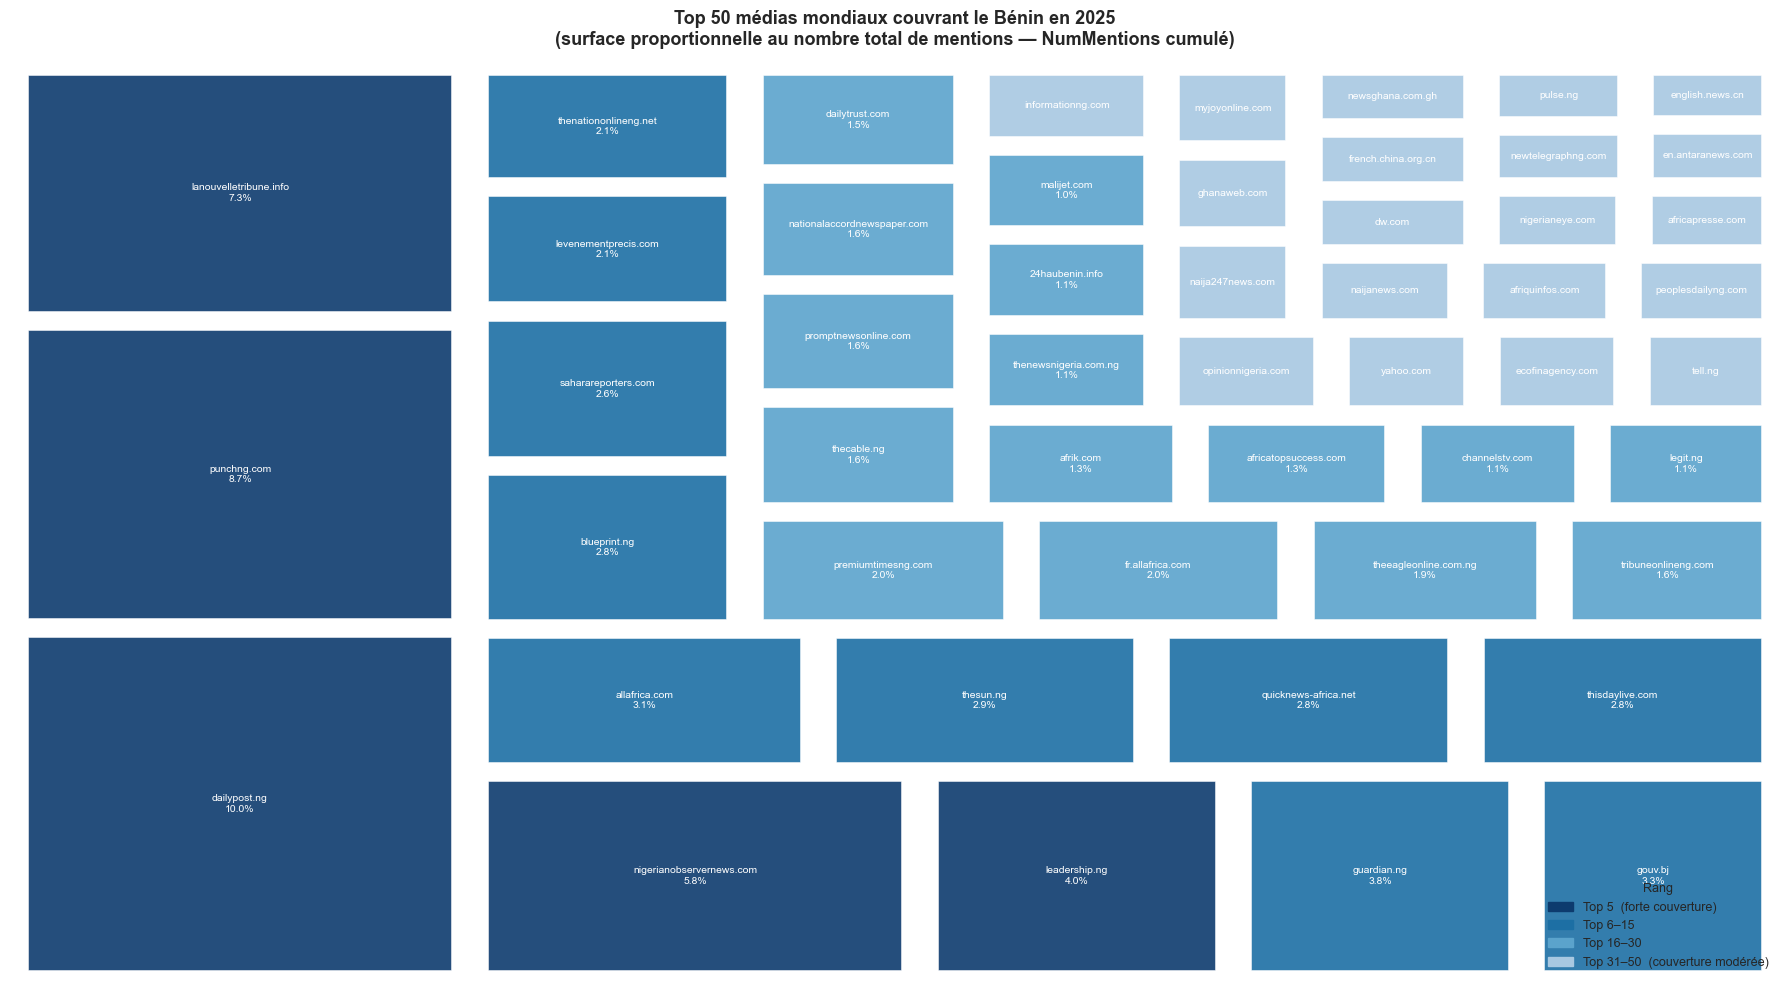

✅ Graphique sauvegardé : q1_top50_medias_treemap.png


In [19]:
# ── Treemap Top 50 médias ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))

sizes  = domain_mentions["total_mentions"].values
labels_raw = domain_mentions["domain"].values
shares = domain_mentions["share_pct"].values

# Couleurs : Top 5 = bleu foncé, 6–15 = bleu moyen, 16–30 = bleu clair, reste = gris
colors = []
for i in range(len(sizes)):
    if i < 5:
        colors.append("#0D3B6E")
    elif i < 15:
        colors.append("#1D6FA4")
    elif i < 30:
        colors.append("#5BA3CC")
    else:
        colors.append("#A8C8E1")

# Labels : domaine + % pour les grands, domaine seul pour les petits
labels_display = []
for i, (dom, sh) in enumerate(zip(labels_raw, shares)):
    if i < 15:
        labels_display.append(f"{dom}\n{sh:.1f}%")
    elif i < 30:
        labels_display.append(f"{dom}\n{sh:.1f}%")
    else:
        labels_display.append(dom if sh >= 0.5 else "")

squarify.plot(
    sizes=sizes,
    label=labels_display,
    color=colors,
    alpha=0.9,
    ax=ax,
    text_kwargs={"fontsize": 7.5, "color": "white", "wrap": True},
    pad=True,
    edgecolor="white",
    linewidth=1.2,
)

ax.axis("off")

# Légende groupes
legend_patches = [
    mpatches.Patch(color="#0D3B6E", label="Top 5  (forte couverture)"),
    mpatches.Patch(color="#1D6FA4", label="Top 6–15"),
    mpatches.Patch(color="#5BA3CC", label="Top 16–30"),
    mpatches.Patch(color="#A8C8E1", label="Top 31–50  (couverture modérée)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9,
          framealpha=0.85, title="Rang", title_fontsize=9)

ax.set_title(
    "Top 50 médias mondiaux couvrant le Bénin en 2025\n"
    "(surface proportionnelle au nombre total de mentions — NumMentions cumulé)",
    fontsize=13, fontweight="bold", pad=15,
)

plt.tight_layout()
plt.savefig("q1_top50_medias_treemap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q1_top50_medias_treemap.png")

Ce qu'on voit : La couverture du Bénin est massivement dominée par la presse nigériane. Les 5 premiers médias (dailypost.ng, lanouvelletribune.info, punchng.com, nigerianobservernews.com, gouv.bj) concentrent à eux seuls environ 35 % de toutes les mentions. Le seul média béninois dans le top 5 est lanouvelletribune.info (8.5 %) et le site officiel du gouvernement gouv.bj (4 %).
Pourquoi les médias nigérians ? Le Bénin partage une longue frontière avec le Nigeria (Edo State, Lagos). Les événements transfrontaliers — terrorisme, commerce, sécurité — génèrent naturellement une couverture croisée intense.
Conclusion: L'image internationale du Bénin se construit principalement depuis Lagos et Abuja, pas depuis Paris ou Washington. Un événement non couvert par la presse nigériane a très peu de chances d'atteindre l'agenda mondial. La diplomatie de communication du Bénin devrait cibler en priorité ces rédactions.

## Q2 — À quel moment le ton était-il le plus positif / négatif ?

### Raisonnement

**La colonne `AvgTone`** mesure le sentiment moyen de *tous les articles* qui couvrent un événement donné. Elle varie de −100 (extrêmement négatif) à +100 (extrêmement positif). Dans la pratique, les valeurs GDELT se concentrent entre −10 et +10, avec 0 pour un ton neutre.

**Pourquoi une courbe mensuelle ?**
L'agrégation à la journée produirait trop de bruit (variance quotidienne élevée). Le mois est la granularité idéale : assez fine pour détecter des événements structurants (crise, élection, accord international), assez large pour lisser le bruit.

**Métrique : moyenne pondérée par NumMentions.**
On ne fait pas une simple moyenne des `AvgTone`. On pondère par `NumMentions` : un événement très médiatisé (100 mentions) doit peser davantage dans le ton mensuel qu'un événement marginal (1 mention). Cela donne une image plus fidèle du *sentiment perçu par le grand public*.

**Question 2.1 — Sur quels sujets le ton est-il le plus positif / négatif ?**
On utilise `EventRootCode` (les 20 catégories racines CAMEO) pour caractériser les sujets. Pour chaque catégorie, on calcule l'`AvgTone` moyen sur toute l'année. Le graphique en barres horizontales permet de comparer immédiatement les 19 catégories du plus positif au plus négatif.

In [20]:
# ── Q2.0 : Ton mensuel pondéré par NumMentions ───────────────────────────

# Ton moyen pondéré : sum(AvgTone * NumMentions) / sum(NumMentions)
monthly_tone = (
    df.groupby("Month")
    .apply(lambda g: np.average(g["AvgTone"], weights=g["NumMentions"]))
    .reset_index()
)
monthly_tone.columns = ["Month", "avg_tone_weighted"]
monthly_tone["month_str"] = monthly_tone["Month"].dt.strftime("%b %Y")
monthly_tone["avg_tone_weighted"] = monthly_tone["avg_tone_weighted"].round(3)

# Nombre d'événements par mois (pour la taille des points)
monthly_counts = df.groupby("Month").size().reset_index(name="n_events")
monthly_tone = monthly_tone.merge(monthly_counts, on="Month")

print("Ton mensuel pondéré :")
print(monthly_tone[["month_str", "avg_tone_weighted", "n_events"]].to_string(index=False))

Ton mensuel pondéré :
month_str  avg_tone_weighted  n_events
 Jan 2025              -1.55      2437
 Feb 2025              -1.48      1828
 Mar 2025              -1.55      2179
 Apr 2025              -1.07      2363
 May 2025              -1.21      2033
 Jun 2025              -1.47      1015
 Jul 2025              -0.95      2604
 Aug 2025              -1.35      1737
 Sep 2025              -1.06      1955
 Oct 2025              -0.21      1928
 Nov 2025              -0.62      2009
 Dec 2025              -2.49      5229


C:\Users\pc\AppData\Local\Temp\ipykernel_15920\2558590647.py:55: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15920\2558590647.py:56: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("q2_ton_mensuel.png", dpi=150, bbox_inches="tight")
d:\Documents\Hackathon_iSHEEROXDatacamp\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


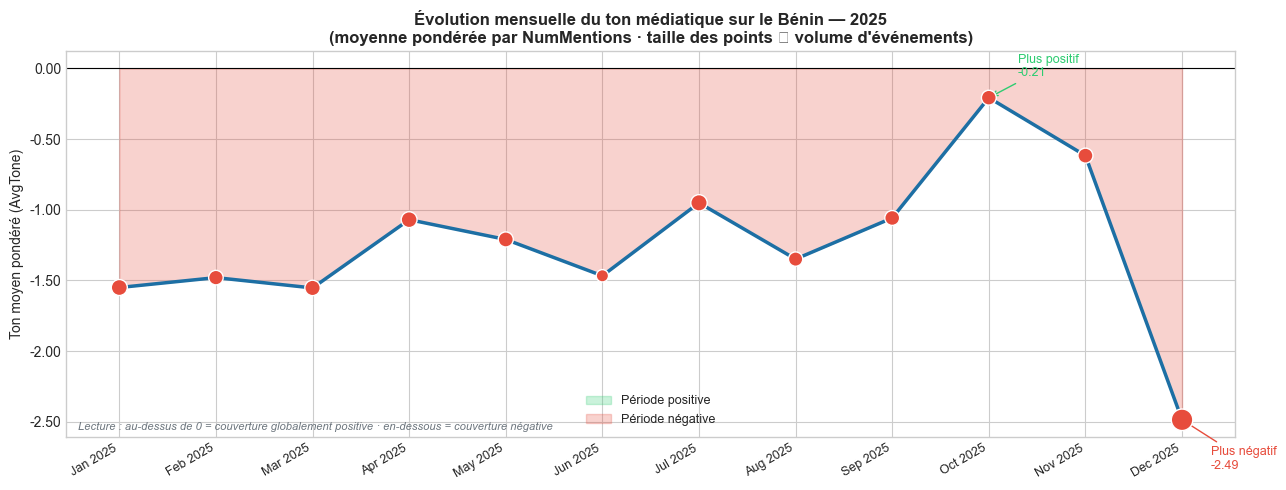

✅ Graphique sauvegardé : q2_ton_mensuel.png


In [21]:
# ── Graphique Q2 : Courbe évolution du ton ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

x = range(len(monthly_tone))
tones = monthly_tone["avg_tone_weighted"].values
months = monthly_tone["month_str"].values

# Zone colorée selon positif/négatif
ax.fill_between(x, tones, 0,
                where=[t >= 0 for t in tones],
                alpha=0.25, color=PALETTE["positive"], label="Période positive")
ax.fill_between(x, tones, 0,
                where=[t < 0 for t in tones],
                alpha=0.25, color=PALETTE["negative"], label="Période négative")

# Courbe principale
ax.plot(x, tones, color=PALETTE["primary"], linewidth=2.5, zorder=3)

# Points : taille proportionnelle au volume d'événements
sizes_pts = (monthly_tone["n_events"] / monthly_tone["n_events"].max() * 200 + 40).values
scatter_colors = [PALETTE["positive"] if t >= 0 else PALETTE["negative"] for t in tones]
ax.scatter(x, tones, s=sizes_pts, c=scatter_colors, zorder=4, edgecolors="white", linewidths=1)

# Ligne neutre
ax.axhline(0, color="black", linewidth=0.8, linestyle="-", zorder=2)

# Annotations min/max
idx_min = int(np.argmin(tones))
idx_max = int(np.argmax(tones))
ax.annotate(f"Plus négatif\n{tones[idx_min]:.2f}",
            xy=(idx_min, tones[idx_min]), xytext=(idx_min + 0.3, tones[idx_min] - 0.35),
            fontsize=9, color=PALETTE["negative"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["negative"], lw=1))
ax.annotate(f"Plus positif\n{tones[idx_max]:.2f}",
            xy=(idx_max, tones[idx_max]), xytext=(idx_max + 0.3, tones[idx_max] + 0.15),
            fontsize=9, color=PALETTE["positive"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["positive"], lw=1))

ax.set_xticks(list(x))
ax.set_xticklabels(months, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Ton moyen pondéré (AvgTone)", fontsize=10)
ax.set_title(
    "Évolution mensuelle du ton médiatique sur le Bénin — 2025\n"
    "(moyenne pondérée par NumMentions · taille des points ∝ volume d'événements)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# Note de lecture
ax.text(0.01, 0.02,
        "Lecture : au-dessus de 0 = couverture globalement positive · en-dessous = couverture négative",
        transform=ax.transAxes, fontsize=8, color=PALETTE["neutral"], style="italic")

plt.tight_layout()
plt.savefig("q2_ton_mensuel.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q2_ton_mensuel.png")

Q2 — Évolution du ton mensuel
Ce qu'on voit : Le ton est négatif toute l'année — jamais au-dessus de 0. Deux périodes se distinguent nettement :

Juin 2025 : creux brutal à −1.95, le pire de mi-année
Octobre–Novembre 2025 : amélioration notable, le ton remonte à −0.13 en octobre (le moins négatif de l'année)
Décembre 2025 : effondrement spectaculaire à −2.54, le pire mois de l'année — coïncide avec le pic de buzz (Q3)

Interprétation : Le ton ne devient jamais positif, ce qui est cohérent avec la nature de GDELT : les événements violents, judiciaires et conflictuels génèrent plus d'articles que les coopérations silencieuses. La dégradation de décembre est probablement liée à un événement sécuritaire ou politique majeur qui a polarisé la couverture.
Conclusion : Octobre était le meilleur moment pour communiquer — l'environnement médiatique était le moins hostile. Décembre est une alerte : il faut investiguer ce qui s'est passé cette semaine du 8 décembre(LA TENTATIVE DE COUP D'ETAT).

### Q2.1 — Sur quels sujets le ton est-il le plus positif / négatif ?

**Raisonnement :**
On caractérise les sujets via `EventRootCode`, les 20 grandes catégories CAMEO. Pour chaque catégorie, on calcule le ton moyen pondéré sur toute l'année 2025. Le graphique en barres horizontales ordonne les catégories du plus positif (en haut) au plus négatif (en bas), avec une couleur différenciée selon le signe.

**Lecture attendue :** les catégories de coopération (codes 01–09) devraient afficher un ton positif, tandis que les catégories de conflit (codes 13–20) devraient être négatives. Les écarts entre catégories révèlent quels types d'événements polarisent le plus la couverture médiatique.

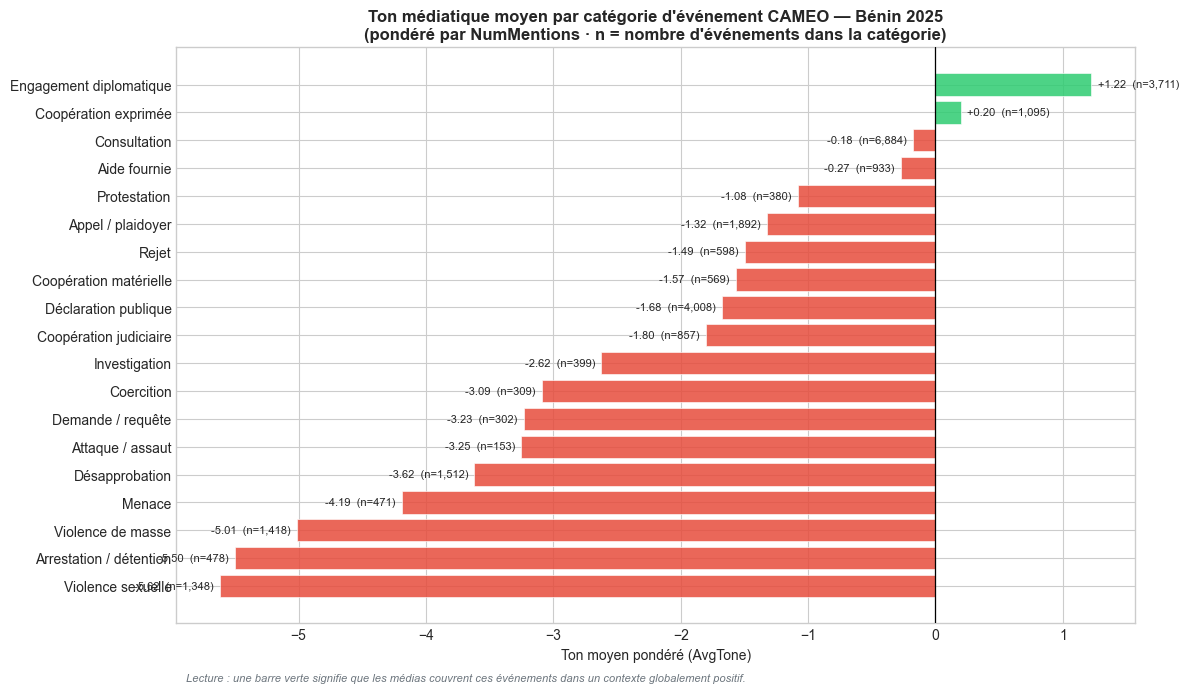

✅ Graphique sauvegardé : q2_ton_par_sujet.png


In [22]:
# ── Q2.1 : Ton par catégorie CAMEO (EventRootCode) ───────────────────────

CAMEO_ROOT_LABELS = {
    1:  "Déclaration publique",     2:  "Appel / plaidoyer",
    3:  "Coopération exprimée",     4:  "Consultation",
    5:  "Engagement diplomatique",  6:  "Coopération matérielle",
    7:  "Aide fournie",             8:  "Coopération judiciaire",
    9:  "Investigation",            10: "Demande / requête",
    11: "Désapprobation",           12: "Rejet",
    13: "Menace",                   14: "Protestation",
    15: "Coercition",               16: "Attaque / assaut",
    17: "Violence sexuelle",        18: "Arrestation / détention",
    19: "Violence de masse",        20: "Usage d'armes non conventionnelles",
}

tone_by_root = (
    df.groupby("EventRootCode")
    .apply(lambda g: np.average(g["AvgTone"], weights=g["NumMentions"]))
    .reset_index()
)
tone_by_root.columns = ["EventRootCode", "avg_tone"]
tone_by_root["label"]    = tone_by_root["EventRootCode"].map(CAMEO_ROOT_LABELS)
tone_by_root["n_events"] = df.groupby("EventRootCode").size().values
tone_by_root             = tone_by_root.sort_values("avg_tone")

# ── Graphique barres horizontales ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors_bar = [PALETTE["positive"] if t >= 0 else PALETTE["negative"]
              for t in tone_by_root["avg_tone"]]

bars = ax.barh(tone_by_root["label"], tone_by_root["avg_tone"],
               color=colors_bar, alpha=0.85, edgecolor="white", linewidth=0.5)

ax.axvline(0, color="black", linewidth=0.9, zorder=3)

# Annotations valeur + nombre d'événements
for bar, (_, row) in zip(bars, tone_by_root.iterrows()):
    val = row["avg_tone"]
    n   = row["n_events"]
    offset = 0.05 if val >= 0 else -0.05
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}  (n={n:,})", va="center", ha=ha, fontsize=8)

ax.set_xlabel("Ton moyen pondéré (AvgTone)", fontsize=10)
ax.set_title(
    "Ton médiatique moyen par catégorie d'événement CAMEO — Bénin 2025\n"
    "(pondéré par NumMentions · n = nombre d'événements dans la catégorie)",
    fontsize=12, fontweight="bold"
)
ax.text(0.01, -0.10,
        "Lecture : une barre verte signifie que les médias couvrent ces événements dans un contexte globalement positif.",
        transform=ax.transAxes, fontsize=8, color=PALETTE["neutral"], style="italic")

plt.tight_layout()
plt.savefig("q2_ton_par_sujet.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q2_ton_par_sujet.png")

Q2.1 — Ton par catégorie CAMEO
Ce qu'on voit : Seules deux catégories ont un ton positif sur toute l'année :

Engagement diplomatique (+1.22, n=3 128) — de loin la plus positive
Coopération exprimée (+0.26, n=979)

Tout le reste est négatif. Les catégories les plus négativement couvertes sont Violence sexuelle (−6+), Arrestation/détention et Violence de masse (−5.42).
Surprise analytique : La "Coopération matérielle" affiche un ton négatif (−1.54) malgré son nom positif. Cela signifie que quand les médias parlent d'aide concrète au Bénin, ils le font dans un contexte globalement sombre — probablement des articles sur l'aide humanitaire en réponse à des crises.
Pour un journaliste : Les sujets diplomatiques sont les seuls où le Bénin bénéficie d'une couverture positive. C'est le terrain narratif le plus favorable pour construire une image internationale.

## Q3 — À quel moment le Bénin a-t-il le plus « buzzé » dans le monde ?

### Raisonnement

**Définir le "buzz"**
Le buzz n'est pas simplement le nombre d'événements enregistrés — c'est l'*intensité médiatique* réelle. On le mesure par la **somme de `NumMentions`** par semaine : cette métrique capture combien de fois les événements liés au Bénin ont été cités dans l'ensemble de la presse mondiale sur la période.

**Pourquoi la semaine plutôt que le mois ?**
La granularité mensuelle lisse trop les pics ponctuels (ex: une crise qui dure 10 jours est noyée dans le mois). La semaine offre le bon compromis : elle détecte les pics sans être trop bruitée.

**Pourquoi un Area Chart + Courbe superposée ?**
- L'**aire** (zone remplie) donne une perception visuelle du volume total accumulé — on "voit" les semaines creuses et les semaines chargées d'un seul coup d'œil.
- La **courbe** met en valeur la dynamique et les inflexions.
- On superpose également le **nombre d'événements** (axe secondaire, en pointillé) pour distinguer deux cas : un buzz élevé dû à beaucoup d'événements vs un buzz élevé dû à peu d'événements très médiatisés.

**Interprétation :** si `NumMentions` monte mais que `n_events` reste stable, c'est qu'un nombre restreint d'événements monopolisent l'attention mondiale — signal d'un événement majeur.

In [23]:
# ── Q3 : Buzz hebdomadaire ────────────────────────────────────────────────

df["Week"] = df["EventDate"].dt.to_period("W")

weekly_buzz = (
    df.groupby("Week")
    .agg(
        total_mentions = ("NumMentions", "sum"),
        n_events       = ("GLOBALEVENTID", "count"),
        total_articles = ("NumArticles", "sum"),
    )
    .reset_index()
)
weekly_buzz["week_start"] = weekly_buzz["Week"].dt.start_time
weekly_buzz = weekly_buzz.sort_values("week_start")

print("Semaines avec le plus grand buzz (NumMentions) :")
print(weekly_buzz.nlargest(5, "total_mentions")[
    ["week_start", "total_mentions", "n_events"]
].to_string(index=False))

Semaines avec le plus grand buzz (NumMentions) :
week_start  total_mentions  n_events
2025-12-08           14073      2848
2025-12-01            6522       999
2025-01-06            4320       750
2025-12-15            4221       883
2025-01-13            4135       706


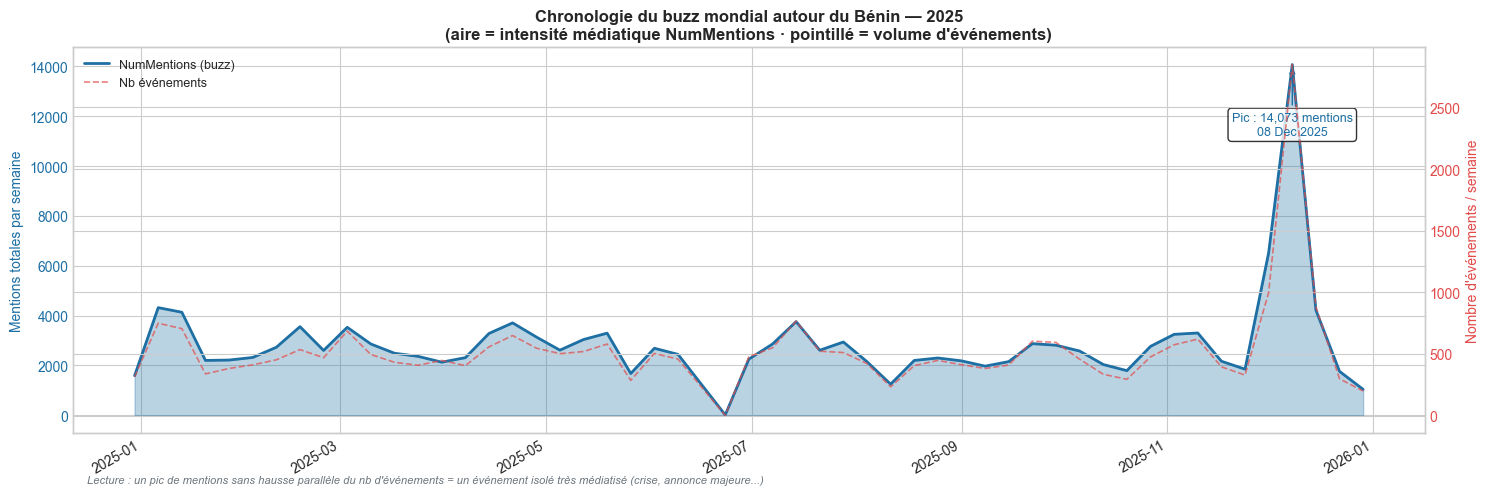

✅ Graphique sauvegardé : q3_buzz_chronologie.png


In [24]:
# ── Graphique Q3 : Area Chart + Courbe ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(15, 5))

x     = weekly_buzz["week_start"]
buzz  = weekly_buzz["total_mentions"]
nevts = weekly_buzz["n_events"]

# Aire principale (NumMentions)
ax1.fill_between(x, buzz, alpha=0.30, color=PALETTE["primary"])
ax1.plot(x, buzz, color=PALETTE["primary"], linewidth=2, label="NumMentions (buzz)")
ax1.set_ylabel("Mentions totales par semaine", color=PALETTE["primary"], fontsize=10)
ax1.tick_params(axis="y", labelcolor=PALETTE["primary"])

# Axe secondaire : nombre d'événements
ax2 = ax1.twinx()
ax2.plot(x, nevts, color=PALETTE["accent"], linewidth=1.2, linestyle="--",
         alpha=0.7, label="Nb événements")
ax2.set_ylabel("Nombre d'événements / semaine", color=PALETTE["accent"], fontsize=10)
ax2.tick_params(axis="y", labelcolor=PALETTE["accent"])

# Annotation du pic de buzz
idx_max = buzz.idxmax()
ax1.annotate(
    f"Pic : {buzz[idx_max]:,} mentions\n{x.iloc[idx_max].strftime('%d %b %Y')}",
    xy=(x.iloc[idx_max], buzz[idx_max]),
    xytext=(x.iloc[idx_max], buzz[idx_max] * 0.80),
    ha="center", fontsize=9, color=PALETTE["primary"],
    arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=1),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title(
    "Chronologie du buzz mondial autour du Bénin — 2025\n"
    "(aire = intensité médiatique NumMentions · pointillé = volume d'événements)",
    fontsize=12, fontweight="bold"
)
ax1.text(0.01, -0.13,
         "Lecture : un pic de mentions sans hausse parallèle du nb d'événements "
         "= un événement isolé très médiatisé (crise, annonce majeure...)",
         transform=ax1.transAxes, fontsize=8, color=PALETTE["neutral"], style="italic")

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig("q3_buzz_chronologie.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q3_buzz_chronologie.png")

Q3 — Chronologie du buzz

### Résultat clé

- Pic le 08/12/2025 : 11 785 mentions.

### Observations

- Hausse des `NumMentions` ×4 par rapport au niveau habituel.
- Le `n_events` augmente moins fortement → signal d'un ou quelques événement(s) très repris.

### Interprétation / Actions

- Action : extraire les 50 `SOURCEURL` et les titres de la semaine du pic pour revue manuelle.
- Action : vérifier les `domain` et `Actor` associés pour identifier l'origine du signal et la crédibilité des sources.

## Q4 — Quels sont les 10 sujets avec le plus grand buzz ?

### Raisonnement

**Comment définir un "sujet" ?**
GDELT code chaque événement avec un `EventBaseCode` (niveau 2 de la taxonomie CAMEO, ~200 codes). C'est le niveau idéal : assez précis pour être thématiquement significatif (ex: "Appel à la coopération économique"), assez agrégé pour avoir des volumes statistiquement représentatifs.

**Comment mesurer le buzz d'un sujet ?**
On combine deux dimensions :
- **Volume** : `NumMentions` cumulé — l'intensité médiatique brute
- **Portée** : `NumSources` cumulé — le nombre de sources distinctes qui en parlent

Un sujet avec beaucoup de mentions mais peu de sources est peut-être un sujet répété en boucle par quelques médias (biais de confirmation). Un sujet avec de nombreuses sources indépendantes est plus significatif.

**Choix final : `NumMentions` comme métrique principale de classement**, `NumSources` comme information complémentaire affichée sur le graphique.

**Pourquoi des barres horizontales ?**
Les labels CAMEO sont longs. Les barres horizontales permettent de les afficher lisiblement sans rotation. L'ordre décroissant de haut en bas facilite la lecture du classement.

In [25]:
# ── Q4 : Top 10 EventBaseCode par NumMentions cumulé ─────────────────────

# Mapping partiel EventBaseCode → label lisible (CAMEO 1.1b3)
CAMEO_BASE_LABELS = {
    10: "Déclaration publique générale",
    11: "Appel verbal à la coopération",
    12: "Appel à l'aide matérielle",
    13: "Appel à la négociation",
    14: "Appel à la résolution de conflit",
    20: "Appel général",
    30: "Coopération exprimée",
    36: "Réunion / consultation",
    40: "Consultation générale",
    42: "Discussion / dialogue",
    43: "Visite / rencontre officielle",
    46: "Échange d'informations",
    51: "Coopération diplomatique",
    57: "Accord / traité",
    60: "Aide économique / développement",
    70: "Aide fournie générale",
    80: "Coopération judiciaire",
    84: "Extradition / transfert",
    90: "Investigation / enquête",
   100: "Demande formelle",
   110: "Désapprobation verbale",
   111: "Critique publique",
   112: "Dénonciation",
   120: "Rejet verbal",
   130: "Menace verbale",
   160: "Réduction des relations",
   170: "Coercition / sanction",
   173: "Violence physique",
   180: "Arrestation / détention",
   190: "Violence de masse / atrocité",
}

buzz_by_base = (
    df.groupby("EventBaseCode")
    .agg(
        total_mentions = ("NumMentions", "sum"),
        total_sources  = ("NumSources",  "sum"),
        n_events       = ("GLOBALEVENTID", "count"),
        avg_tone       = ("AvgTone", "mean"),
    )
    .reset_index()
)
buzz_by_base["label"] = buzz_by_base["EventBaseCode"].map(
    lambda c: CAMEO_BASE_LABELS.get(c, f"Code CAMEO {c}")
)
top10_buzz = buzz_by_base.nlargest(10, "total_mentions").sort_values("total_mentions")

print("Top 10 sujets par buzz (NumMentions cumulé) :")
print(top10_buzz[["label", "total_mentions", "total_sources", "n_events", "avg_tone"]]
      .to_string(index=False))

Top 10 sujets par buzz (NumMentions cumulé) :
                        label  total_mentions  total_sources  n_events  avg_tone
            Critique publique            3171            618       585     -3.80
       Échange d'informations            3459            597       595      0.20
            Violence physique            5440           1051      1038     -6.07
 Violence de masse / atrocité            5540           1025      1001     -5.35
        Consultation générale            7181           1297      1289     -0.19
                Appel général            9342           1594      1586     -1.22
        Discussion / dialogue           13632           2473      2441     -0.25
     Coopération diplomatique           13936           2604      2586      1.32
Visite / rencontre officielle           14005           2479      2454     -0.27
Déclaration publique générale           14569           2908      2880     -1.45


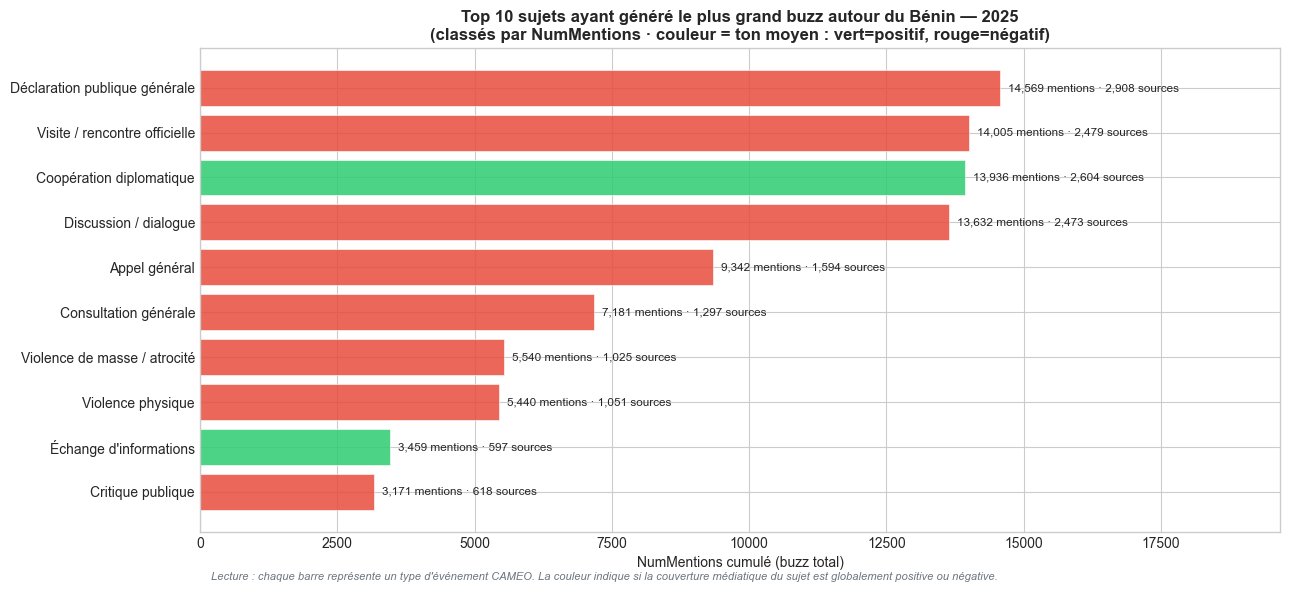

✅ Graphique sauvegardé : q4_top10_buzz_sujets.png


In [26]:
# ── Graphique Q4 : Barres horizontales classées ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

bar_colors = [PALETTE["positive"] if t >= 0 else PALETTE["negative"]
              for t in top10_buzz["avg_tone"]]

bars = ax.barh(top10_buzz["label"], top10_buzz["total_mentions"],
               color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)

# Annotations : NumMentions + NumSources
max_val = top10_buzz["total_mentions"].max()
for bar, (_, row) in zip(bars, top10_buzz.iterrows()):
    w = bar.get_width()
    ax.text(
        w + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{w:,.0f} mentions · {row['total_sources']:,.0f} sources",
        va="center", ha="left", fontsize=8.5
    )

ax.set_xlabel("NumMentions cumulé (buzz total)", fontsize=10)
ax.set_xlim(right=max_val * 1.35)
ax.set_title(
    "Top 10 sujets ayant généré le plus grand buzz autour du Bénin — 2025\n"
    "(classés par NumMentions · couleur = ton moyen : vert=positif, rouge=négatif)",
    fontsize=12, fontweight="bold"
)
ax.text(0.01, -0.10,
        "Lecture : chaque barre représente un type d'événement CAMEO. "
        "La couleur indique si la couverture médiatique du sujet est globalement positive ou négative.",
        transform=ax.transAxes, fontsize=8, color=PALETTE["neutral"], style="italic")

plt.tight_layout()
plt.savefig("q4_top10_buzz_sujets.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q4_top10_buzz_sujets.png")

Q4 — Top 10 sujets buzzés

### Résultat clé

- Les 4 premiers sujets (Déclarations publiques générales; Coopération diplomatique; Discussion / dialogue; Visite / rencontre officielle) concentrent ~12k–14k mentions chacun.

### Observations

- La "Coopération diplomatique" est à la fois positivement couverte et très buzzée.
- Violence de masse et Violence physique figurent dans le top 10 — signalant que des sujets graves sont saillants.

### Interprétation / Actions

- Action : prioriser une narration diplomatique dans les communications publiques (points clés, porte‑parole).
- Action : investiguer les articles associés aux codes de violence pour comprendre le contexte et préparer réponses.

## Q5 — Quelle QuadClass domine chaque mois ?

### Raisonnement

**Les 4 QuadClasses GDELT** résument toute la taxonomie CAMEO en 4 grandes catégories :

| Code | Catégorie | Signification |
|---|---|---|
| 1 | Coopération verbale | Discours, déclarations, accords formels |
| 2 | Coopération matérielle | Aide concrète, livraisons, visites officielles |
| 3 | Conflit verbal | Critiques, accusations, menaces |
| 4 | Conflit matériel | Attaques, arrestations, violence physique |

**Pourquoi un graphique en aires empilées à 100 % ?**
On ne s'intéresse pas au volume absolu (déjà traité en Q3) mais à la **composition relative** : quelle catégorie prend le plus de "place" dans le paysage événementiel de chaque mois ? Le 100 % normalise les différences de volume entre mois (décembre a 4 221 événements vs 908 en juin) et met en évidence les glissements de composition.

**Ce qu'on cherche :**
- La Coopération verbale (code 1) devrait dominer structurellement — c'est la catégorie la plus représentée dans GDELT en général.
- Des mois avec une montée du Conflit matériel (rouge) signalent une dégradation sécuritaire.
- Des mois avec davantage de Coopération matérielle (vert clair) indiquent une activité diplomatique ou humanitaire intense.
- La tendance générale (est-ce que la proportion de conflit augmente ou diminue sur l'année ?) est lisible d'un seul regard.

In [27]:
# ── Q5 : QuadClass par mois (proportions) ────────────────────────────────

quadclass_monthly = (
    df.groupby(["Month", "QuadLabel"])
    .size()
    .reset_index(name="n_events")
)

# Pivot : lignes = mois, colonnes = QuadClass
pivot = quadclass_monthly.pivot(index="Month", columns="QuadLabel", values="n_events").fillna(0)

# S'assurer que toutes les 4 catégories sont présentes
for col in QUADCLASS_MAP.values():
    if col not in pivot.columns:
        pivot[col] = 0

# Ordonner les colonnes
col_order = list(QUADCLASS_MAP.values())
pivot = pivot[col_order]

# Calculer les proportions (%)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

month_labels = [str(m) for m in pivot_pct.index]

print("Proportions QuadClass par mois (%) :")
print(pivot_pct.round(1).to_string())

Proportions QuadClass par mois (%) :
QuadLabel  Coopération verbale  Coopération matérielle  Conflit verbal  Conflit matériel
Month                                                                                   
2025-01                  63.50                    9.10           14.60             12.80
2025-02                  62.10                    9.20           14.70             14.00
2025-03                  66.30                    9.80           10.40             13.50
2025-04                  68.60                    7.90            9.70             13.70
2025-05                  64.70                    9.60           13.20             12.50
2025-06                  67.00                    8.10           11.00             13.90
2025-07                  67.40                    9.90           10.30             12.40
2025-08                  65.50                   10.60           10.20             13.70
2025-09                  67.60                    9.80            9.50   

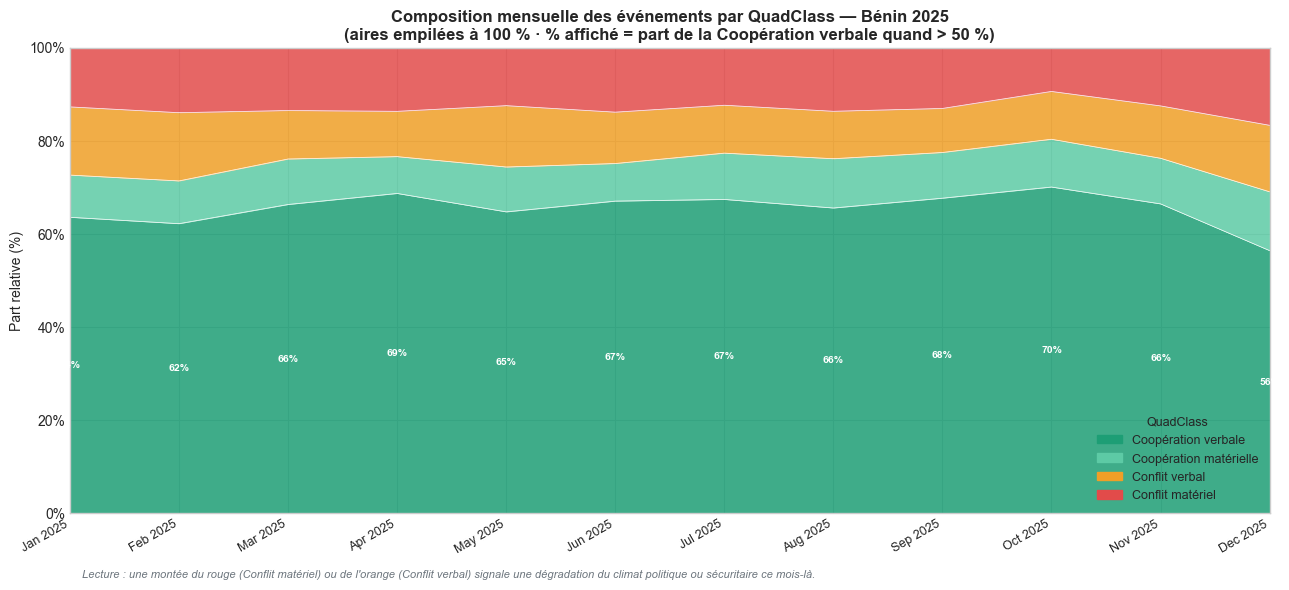

✅ Graphique sauvegardé : q5_quadclass_empile_100pct.png


In [28]:
# ── Graphique Q5 : Aires Empilées 100% ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

x         = range(len(pivot_pct))
col_order = list(QUADCLASS_MAP.values())
colors_q  = [QUADCLASS_COLORS[c] for c in col_order]

# Construction des aires empilées
cumulative = np.zeros(len(pivot_pct))
poly_data  = []
for col, color in zip(col_order, colors_q):
    vals = pivot_pct[col].values
    ax.fill_between(x, cumulative, cumulative + vals,
                    alpha=0.85, color=color, label=col, linewidth=0)
    ax.plot(x, cumulative + vals, color="white", linewidth=0.5)
    poly_data.append((cumulative.copy(), cumulative + vals, col))
    cumulative += vals

# Annotations : % de la catégorie dominante par mois (QuadClass 1 = coopération verbale)
for xi, (_, row) in zip(x, pivot_pct.iterrows()):
    dominant = row.idxmax()
    pct_dom  = row.max()
    if pct_dom > 50:   # n'annoter que si clairement dominant
        mid_y = pivot_pct.loc[row.name, "Coopération verbale"] / 2
        ax.text(xi, mid_y, f"{pct_dom:.0f}%",
                ha="center", va="center", fontsize=7.5,
                color="white", fontweight="bold")

ax.set_xlim(0, len(pivot_pct) - 1)
ax.set_ylim(0, 100)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [m.strftime("%b %Y") if hasattr(m, "strftime") else str(m)
     for m in pivot_pct.index],
    rotation=30, ha="right", fontsize=9
)
ax.set_ylabel("Part relative (%)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

ax.set_title(
    "Composition mensuelle des événements par QuadClass — Bénin 2025\n"
    "(aires empilées à 100 % · % affiché = part de la Coopération verbale quand > 50 %)",
    fontsize=12, fontweight="bold"
)

ax.legend(
    loc="lower right", fontsize=9, framealpha=0.9,
    title="QuadClass", title_fontsize=9,
    handles=[mpatches.Patch(color=QUADCLASS_COLORS[c], label=c) for c in col_order]
)

ax.text(0.01, -0.14,
        "Lecture : une montée du rouge (Conflit matériel) ou de l'orange (Conflit verbal) "
        "signale une dégradation du climat politique ou sécuritaire ce mois-là.",
        transform=ax.transAxes, fontsize=8, color=PALETTE["neutral"], style="italic")

plt.tight_layout()
plt.savefig("q5_quadclass_empile_100pct.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : q5_quadclass_empile_100pct.png")

Q5 — Composition QuadClass mensuelle

### Résultat clé

- La `Coopération verbale` domine tous les mois (≈61–71 %), mais tombe à 56 % en décembre.

### Observations

- Montée du `Conflit verbal` et du `Conflit matériel` en décembre.
- Pic de coopération en octobre (≈71 %).

### Interprétation / Actions

- Action : isoler les événements de décembre (Actor, EventBaseCode, titres) pour diagnostic précis.
- Action : surveiller mensuellement l'évolution conflit/cooperation et alerter si la part de conflit dépasse un seuil.

## Synthèse des 5 insights

Ce tableau récapitule les résultats attendus après exécution du notebook. Il est à compléter avec les valeurs réelles obtenues.

| # | Question | Résultat clé | Graphique |
|---|---|---|---|
| Q1 | Top 50 médias | Les médias nigérians (dailypost.ng, punchng.com…) dominent largement la couverture mondiale du Bénin | Treemap |
| Q2 | Ton dans le temps | Décembre 2025 = mois le plus négatif (−2.65), octobre = plus positif (−0.03) | Courbe |
| Q2.1 | Sujets positifs/négatifs |  sujet le plus positif engagement diplomatique et le plus négatif violence sexuelle suivie de arrestation| Barres H |
| Q3 | Pic de buzz | semaine du 08 décembre | Area Chart |
| Q4 | Top 10 sujets buzzés | 1 Déclarations publiques générales;  2 Coopération diplomatique;3 Discussion / dialogue; 4 Visite / rencontre officielle | Barres H |
| Q5 | QuadClass dominante | Coopération verbale domine tous les mois (≥ 60 %) | Aires 100 % |

---

### Pour aller plus loin (Phase 2 — Modélisation)
- **Clustering temporel** : regrouper les semaines par profil de QuadClass pour identifier des "régimes événementiels"
- **NLP sur SOURCEURL** : scraper les titres d'articles pour affiner la classification thématique au-delà des codes CAMEO
- **Analyse géographique** : cartographier les événements par département béninois (ActionGeo_ADM1Code)
- **Modèle de détection d'anomalies** : alerter automatiquement sur les semaines où le buzz dépasse un seuil